# Artificial Neuron for Real Estate Price Prediction

## Objective
The objective of this notebook is to implement a single artificial neuron from scratch using NumPy and train it on a Real Estate Price Prediction dataset.

The neuron will learn the relationship between selected property features and house prices using:

- Forward Propagation
- Mean Squared Error (MSE) Loss
- Gradient Descent
- Backpropagation

No machine learning library (such as Scikit-Learn or TensorFlow) will be used for training.


## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## Dataset Loading

The dataset is stored in the same folder as this notebook.

We first load the dataset and inspect its structure to identify:
- Input Features
- Target Variable
- Missing Values
- Data Types


In [2]:
# Replace real_estate.csv with your actual filename
df = pd.read_csv("real_estate.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (414, 8)


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


## Understanding the Dataset

Each row represents a property.

Typical features may include:

- House Age
- Distance to MRT Station
- Number of Convenience Stores
- Latitude
- Longitude

Target:

- House Price per Unit Area

The artificial neuron will learn how these features influence property prices.


In [4]:
print(df.isnull().sum())
df = df.dropna()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


## Feature Selection

For this experiment we select the numerical property attributes as inputs.

The target variable is the house price.


In [26]:
X = df[['X2 house age',
        'X3 distance to the nearest MRT station',
        'X4 number of convenience stores',
        'X5 latitude',
        'X6 longitude'
        ]].values

y = df['Y house price of unit area'].values

## Feature Normalization

Features often have different scales.

For example:

- House Age → 0 to 50
- Distance to MRT → 0 to 6000

Without normalization, gradient descent may converge slowly or become unstable.

We therefore standardize each feature using Z-score normalization.


In [28]:
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)

X_scaled = (X - X_mean) / X_std

In [29]:
X_scaled

array([[ 1.25562833, -0.79249504,  2.00740743,  1.12542986,  0.44876222],
       [ 0.15708622, -0.61661163,  1.66750286,  0.91244418,  0.40113894],
       [-0.38779067, -0.41401527,  0.30788458,  1.48686011,  0.68818339],
       ...,
       [ 0.09556786, -0.54967846,  0.98769372,  0.82289338,  0.42397202],
       [-0.84478419, -0.77668389,  0.30788458, -0.18475479,  0.4768143 ],
       [-0.98539758, -0.78807071,  1.66750286,  0.42757905,  0.63534112]],
      shape=(414, 5))

In [33]:
y.shape

(414,)

## Artificial Neuron Model

The neuron computes:

\[
z = w_1x_1 + w_2x_2 + ... + w_nx_n + b
\]

Since this is a regression problem:

\[
\hat{y} = z
\]

Where:

- \(x_i\) = input features
- \(w_i\) = weights
- \(b\) = bias
- \(\hat{y}\) = predicted house price


In [34]:
n_features = X_scaled.shape[1]

w = np.random.randn(n_features)
b = np.random.randn()

learning_rate = 0.01
max_epochs = 5000
tolerance = 1e-7

## Training the Artificial Neuron

Training consists of:

1. Forward Propagation
2. Loss Computation
3. Gradient Calculation
4. Weight Update using Gradient Descent

The objective is to minimize Mean Squared Error (MSE).


In [35]:
loss_history = []

print("Training Started...\n")

for epoch in range(max_epochs):

    # Forward Propagation
    y_pred = np.dot(X_scaled, w) + b

    # MSE Loss
    loss = np.mean((y_pred - y) ** 2)

    loss_history.append(loss)

    # Backpropagation
    n = len(X_scaled)

    dL_dw = (2 / n) * np.dot(X_scaled.T, (y_pred - y))
    dL_db = (2 / n) * np.sum(y_pred - y)

    # Gradient Descent Update
    new_w = w - learning_rate * dL_dw
    new_b = b - learning_rate * dL_db

    # Convergence Check
    if np.all(np.abs(new_w - w) < tolerance) and abs(new_b - b) < tolerance:

        print(f"Converged at Epoch {epoch}")

        w = new_w
        b = new_b

        break

    w = new_w
    b = new_b

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | MSE = {loss:.4f}")

print("\nTraining Complete")

Training Started...

Epoch    0 | MSE = 1526.5790
Epoch  500 | MSE = 79.2169
Epoch 1000 | MSE = 79.2026
Epoch 1500 | MSE = 79.2019
Epoch 2000 | MSE = 79.2019
Epoch 2500 | MSE = 79.2019
Epoch 3000 | MSE = 79.2019
Converged at Epoch 3443

Training Complete


## Loss Curve

The loss curve shows how the neuron improves during training.

A decreasing loss indicates successful learning.


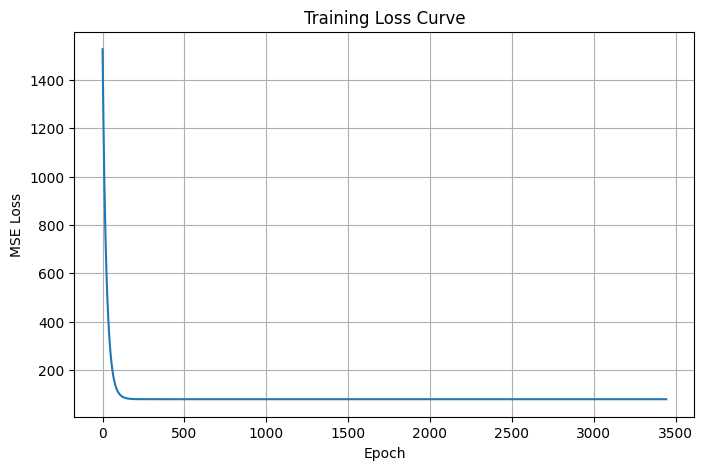

In [36]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

## Model Evaluation

The performance of the neuron is evaluated using the coefficient of determination (R² Score).

R² measures how much variance in house prices is explained by the model.


In [37]:
final_predictions = np.dot(X_scaled, w) + b

ss_tot = np.sum((y - np.mean(y)) ** 2)

ss_res = np.sum((y - final_predictions) ** 2)

r2_score = 1 - (ss_res / ss_tot)

print("Learned Weights:\n", w)

print("\nBias:", b)

print(f"\nR² Score: {r2_score:.4f}")

print(f"Accuracy Interpretation: {r2_score * 100:.2f}%")

Learned Weights:
 [-3.0599291  -5.36890819  3.42161545  2.94717958 -0.11962306]

Bias: 37.98019323671422

R² Score: 0.5712
Accuracy Interpretation: 57.12%


## Actual vs Predicted Prices

If the neuron performs well, the predicted prices should closely follow the actual prices.


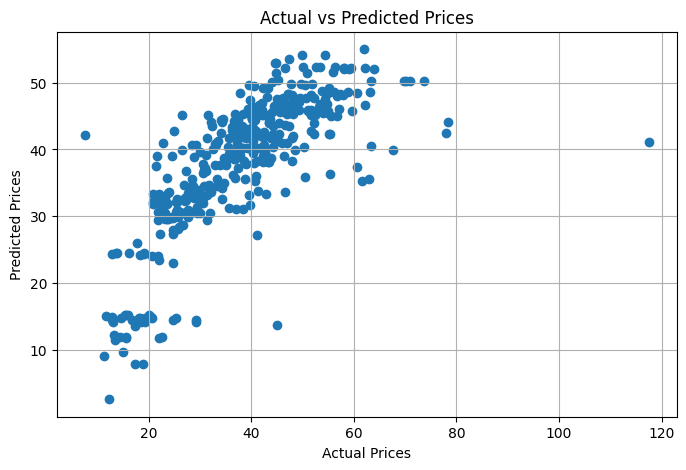

In [38]:
plt.figure(figsize=(8,5))

plt.scatter(y, final_predictions)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.grid(True)

plt.show()

## Predicting a New House Price

After training, the neuron can estimate the price of a new property by applying the learned weights and bias.


In [39]:
# Replace values according to your dataset

new_house = np.array([
    20.0,
    500.0,
    5.0,
    24.97,
    121.54
])

new_house_scaled = (new_house - X_mean) / X_std

predicted_price = np.dot(new_house_scaled, w) + b

print("Predicted House Price:", predicted_price)

Predicted House Price: 41.0841387940814


## Conclusion

A single artificial neuron was implemented from scratch using NumPy and trained on a Real Estate Price Prediction dataset.

The model successfully learned the relationship between property attributes and house prices using gradient descent optimization.

Key concepts demonstrated:

- Artificial Neuron
- Forward Propagation
- Backpropagation
- Mean Squared Error
- Gradient Descent
- Regression Analysis

This notebook provides a foundational understanding of how neural networks learn before moving to multilayer architectures.
